# Imports

In [1]:
from data import *
from models import *
from optim import *
from results_utils import *
from scripts import *
from trainer import *
from itertools import combinations
import certifi
import os
import ssl

In [ ]:
os.environ['SSL_CERT_FILE'] = certifi.where()
os.environ['SSL_CERT_DIR'] = os.path.dirname(certifi.where())

if not os.path.exists(certifi.where()):
    ssl._create_default_https_context = ssl._create_unverified_context
import urllib.request
SEED = 12345

# Load data

In [2]:
# Load datasets
print("Loading Fashion-MNIST...")
X_train_fmnist, y_train_fmnist, X_test_fmnist, y_test_fmnist = load_fashion_mnist()
print(f"Fashion-MNIST: train={X_train_fmnist.shape}, test={X_test_fmnist.shape}")

print("\nLoading CIFAR-10...")
X_train_cifar, y_train_cifar, X_test_cifar, y_test_cifar = load_cifar10()
print(f"CIFAR-10: train={X_train_cifar.shape}, test={X_test_cifar.shape}")


Loading Fashion-MNIST...
Fashion-MNIST: train=(60000, 784), test=(10000, 784)

Loading CIFAR-10...
CIFAR-10: train=(50000, 3072), test=(10000, 3072)


In [3]:
# Standardize and apply PCA
n_components = 100

print("\nProcessing Fashion-MNIST...")
X_train_fmnist_std, X_test_fmnist_std = standardize(X_train_fmnist, X_test_fmnist)
X_train_fmnist_pca, pca_mean_fmnist, pca_components_fmnist = pca_fit_transform(
    X_train_fmnist_std, n_components
)
X_test_fmnist_pca = pca_transform(X_test_fmnist_std, pca_mean_fmnist, pca_components_fmnist)

print("\nProcessing CIFAR-10...")
X_train_cifar_std, X_test_cifar_std = standardize(X_train_cifar, X_test_cifar)
X_train_cifar_pca, pca_mean_cifar, pca_components_cifar = pca_fit_transform(
    X_train_cifar_std, n_components
)
X_test_cifar_pca = pca_transform(X_test_cifar_std, pca_mean_cifar, pca_components_cifar)

print(f"\nFinal shapes:")
print(f"  Fashion-MNIST: train={X_train_fmnist_pca.shape}, test={X_test_fmnist_pca.shape}")
print(f"  CIFAR-10: train={X_train_cifar_pca.shape}, test={X_test_cifar_pca.shape}")



Processing Fashion-MNIST...
PCA: 100 components, explained variance: 0.872

Processing CIFAR-10...
PCA: 100 components, explained variance: 0.898

Final shapes:
  Fashion-MNIST: train=(60000, 100), test=(10000, 100)
  CIFAR-10: train=(50000, 100), test=(10000, 100)


In [4]:
T = 100
n_clusters = 20
n_train_per_task, n_test_per_task = 64, 128
rng = np.random.default_rng(SEED)

# Generate tasks for Fashion-MNIST
## Clustered tasks
X_tr_c, y_tr_c, X_te_c, y_te_c, class_pairs_c, cluster_ids = (
    generate_clustered_binary_tasks(
        X_train_fmnist_pca, y_train_fmnist,
        X_test_fmnist_pca, y_test_fmnist,
        n_tasks=T,
        n_clusters=n_clusters,
        n_train_per_task=n_train_per_task,
        n_test_per_task=n_test_per_task,
        rng=rng,
    )
)

## Homogeneous tasks
X_tr, y_tr, X_te, y_te, class_pairs = (
    generate_binary_tasks(
        X_train_fmnist_pca, y_train_fmnist,
        X_test_fmnist_pca, y_test_fmnist,
        n_tasks=T,
        n_train_per_task=n_train_per_task,
        n_test_per_task=n_test_per_task,
        task_type='random_pairs',
        rng=rng,
    )
)

# Generate tasks for CIFAR-10
## Clustered tasks
X_tr_c_cifar, y_tr_c_cifar, X_te_c_cifar, y_te_c_cifar, class_pairs_c_cifar, cluster_ids_cifar = (
    generate_clustered_binary_tasks(
        X_train_cifar_pca, y_train_cifar,
        X_test_cifar_pca, y_test_cifar,
        n_tasks=T,
        n_clusters=n_clusters,
        n_train_per_task=n_train_per_task,
        n_test_per_task=n_test_per_task,
        rng=rng,
    )
)
## Homogeneous tasks
X_tr_cifar, y_tr_cifar, X_te_cifar, y_te_cifar, class_pairs_cifar = (
    generate_binary_tasks(
        X_train_cifar_pca, y_train_cifar,
        X_test_cifar_pca, y_test_cifar,
        n_tasks=T,
        n_train_per_task=n_train_per_task,
        n_test_per_task=n_test_per_task,
        task_type='random_pairs',
        rng=rng,
    )
)

# Optimization  

### f-MNIST

In [5]:
VAL_SIZE = 32
OPTIMIZE = False
clustered = True

if clustered:
    X_train_optim = {k: X_tr_c[k] for k in range(X_tr_c.shape[0])}
    y_train_optim = {k: y_tr_c[k] for k in range(y_tr_c.shape[0])}
    X_test_optim = {k: X_te_c[k] for k in range(X_te_c.shape[0])}
    y_test_optim = {k: y_te_c[k] for k in range(y_te_c.shape[0])}
else:
    X_train_optim = {k: X_tr[k] for k in range(X_tr.shape[0])}
    y_train_optim = {k: y_tr[k] for k in range(y_tr.shape[0])}
    X_test_optim = {k: X_te[k] for k in range(X_te.shape[0])}
    y_test_optim = {k: y_te[k] for k in range(y_te.shape[0])}

nodes_train = set(X_train_optim.keys())
nodes_test = set(X_test_optim.keys())
nodes = sorted(nodes_train & nodes_test)

print("="*60)
print(f"Train nodes: {len(nodes_train)}")
print(f"Test nodes: {len(nodes_test)}")
print(f"Common nodes: {len(nodes)}")

# Split training data into training and validation sets
X_train_n, y_train_n = {}, {}
X_val_n, y_val_n = {}, {}
X_test_n = {}
node_stats = {}

for v in nodes:
    Xn, yn, stats = normalize_xy(X_train_optim[v], y_train_optim[v])
    node_stats[v] = stats

    X_val_n[v], y_val_n[v] = Xn[:VAL_SIZE], yn[:VAL_SIZE]
    X_train_n[v], y_train_n[v] = Xn[VAL_SIZE:], yn[VAL_SIZE:]

    X_test_n[v] = (X_te_c[v] - stats["X_mean"]) / stats["X_std"]

# Select global root
global_root = select_seed_node(X_train_optim, y_train_optim)

tree_config = {
    "seed": global_root,
}

B = 300
cascade_config = {
    "B": B,
    "device": DEVICE,
    "task": "classification",
    "model_class": "logistic",
}

optim_space = {
    "eta": ("loguniform", 0.001, 0.3),
    "reg": ("loguniform", 1e-6, 1e-2),
    "b_proto_frac": ("uniform", 0.1, 0.9),
}

global_mse = lambda mses: float(np.mean(list(mses.values())))
optimizer = OptunaCascadeOptimizer(
    eval_fn=global_mse,
    optim_space=optim_space,
    n_trials=200,
    seed=SEED,
)

if OPTIMIZE:
    print("\n" + "=" * 60)
    print("Running Optimization")
    print("=" * 60)
    best_params = optimizer.run(
        build_tree_fn=build_mst_tree,
        cascade_train_fn=cascade_train_tree,
        evaluate_models_fn=lambda models: evaluate_on_validation_logistic(
            models, X_val_n, y_val_n
        ),
        base_tree_kwargs={
            "V": nodes,
            "y": {v: y_train_n[v].flatten() for v in nodes},
            **tree_config,
        },
        base_cascade_kwargs={
            "X_train_n": X_train_n,
            "y_train_n": y_train_n,
            **cascade_config,
        },
        B=B,
        model_class="logistic",
    )

Train nodes: 100
Test nodes: 100
Common nodes: 100


### CIFAR-10

In [6]:
OPTIMIZE = False
clustered = True

if clustered:
    X_train_optim = {k: X_tr_c_cifar[k] for k in range(X_tr_c_cifar.shape[0])}
    y_train_optim = {k: y_tr_c_cifar[k] for k in range(y_tr_c_cifar.shape[0])}
    X_test_optim = {k: X_te_c[k] for k in range(X_te_c_cifar.shape[0])}
    y_test_optim = {k: y_te_c[k] for k in range(y_te_c_cifar.shape[0])}
else:
    X_train_optim = {k: X_tr_cifar[k] for k in range(X_tr_cifar.shape[0])}
    y_train_optim = {k: y_tr_cifar[k] for k in range(y_tr_cifar.shape[0])}
    X_test_optim = {k: X_te_cifar[k] for k in range(X_te_cifar.shape[0])}
    y_test_optim = {k: y_te[k] for k in range(y_te_cifar.shape[0])}

nodes_train = set(X_train_optim.keys())
nodes_test = set(X_test_optim.keys())
nodes = sorted(nodes_train & nodes_test)

print("="*60)
print(f"Train nodes: {len(nodes_train)}")
print(f"Test nodes: {len(nodes_test)}")
print(f"Common nodes: {len(nodes)}")

# Split training data into training and validation sets
X_train_n, y_train_n = {}, {}
X_val_n, y_val_n = {}, {}
X_test_n = {}
node_stats = {}

for v in nodes:
    Xn, yn, stats = normalize_xy(X_train_optim[v], y_train_optim[v])
    node_stats[v] = stats

    X_val_n[v], y_val_n[v] = Xn[:VAL_SIZE], yn[:VAL_SIZE]
    X_train_n[v], y_train_n[v] = Xn[VAL_SIZE:], yn[VAL_SIZE:]

    X_test_n[v] = (X_te_c[v] - stats["X_mean"]) / stats["X_std"]

# Select global root
global_root = select_seed_node(X_train_optim, y_train_optim)

tree_config = {
    # "pruning": "ball_soft",
    # "ball_slack_mode": "additive",
    # "k_neighbors": 10,
    "seed": global_root,
}

B = 300
cascade_config = {
    "B": B,
    "device": DEVICE,
    "task": "classification",
    "model_class": "logistic",
}

optim_space = {
    "eta": ("loguniform", 0.001, 0.3),
    "reg": ("loguniform", 1e-6, 1e-2),
    "b_proto_frac": ("uniform", 0.1, 0.9),
    # "ball_top_q": ("uniform", 0.1, 0.9),
}

global_mse = lambda mses: float(np.mean(list(mses.values())))
optimizer = OptunaCascadeOptimizer(
    eval_fn=global_mse,
    optim_space=optim_space,
    n_trials=200,
    seed=SEED,
)

if OPTIMIZE:
    print("\n" + "=" * 60)
    print("Running Optimization")
    print("=" * 60)
    best_params = optimizer.run(
        build_tree_fn=build_mst_tree,
        cascade_train_fn=cascade_train_tree,
        evaluate_models_fn=lambda models: evaluate_on_validation_logistic(
            models, X_val_n, y_val_n
        ),
        base_tree_kwargs={
            "V": nodes,
            "y": {v: y_train_n[v].flatten() for v in nodes},
            **tree_config,
        },
        base_cascade_kwargs={
            "X_train_n": X_train_n,
            "y_train_n": y_train_n,
            **cascade_config,
        },
        B=B,
        model_class="logistic",
    )

Train nodes: 100
Test nodes: 100
Common nodes: 100


Fashion-MNIST Experiments

Image Classification Experiment
Tasks (T): (200,)
Budgets (B): (500,)
Samples per task: train=64, test=128
Learning rate: 0.2955513127628392
Regularization: 0.00790085761024867
Repeats: 3
Seed fraction: 0.1
Clustered: True
Task type: random_pairs
MST variants: ('gradient', 'model', 'wasserstein')
Device: mps


Configuration: T=200, B=500

Repeat 1/3
  Running Individual...
  Running Star...
  Running Random Tree...
  Running MST variants...
  Indiv=0.959, Star=0.961, Rand=0.953, MST[gra=0.974, mod=0.965, was=0.964]

Repeat 2/3
  Running Individual...
  Running Star...
  Running Random Tree...
  Running MST variants...
  Indiv=0.872, Star=0.869, Rand=0.870, MST[gra=0.910, mod=0.866, was=0.849]

Repeat 3/3
  Running Individual...
  Running Star...
  Running Random Tree...
  Running MST variants...
  Indiv=0.810, Star=0.825, Rand=0.861, MST[gra=0.896, mod=0.837, was=0.836]

SUMMARY TABLE: Accuracy (%)
  T   B        Indiv         Star CTL-RandTree CTL-MST-gradie

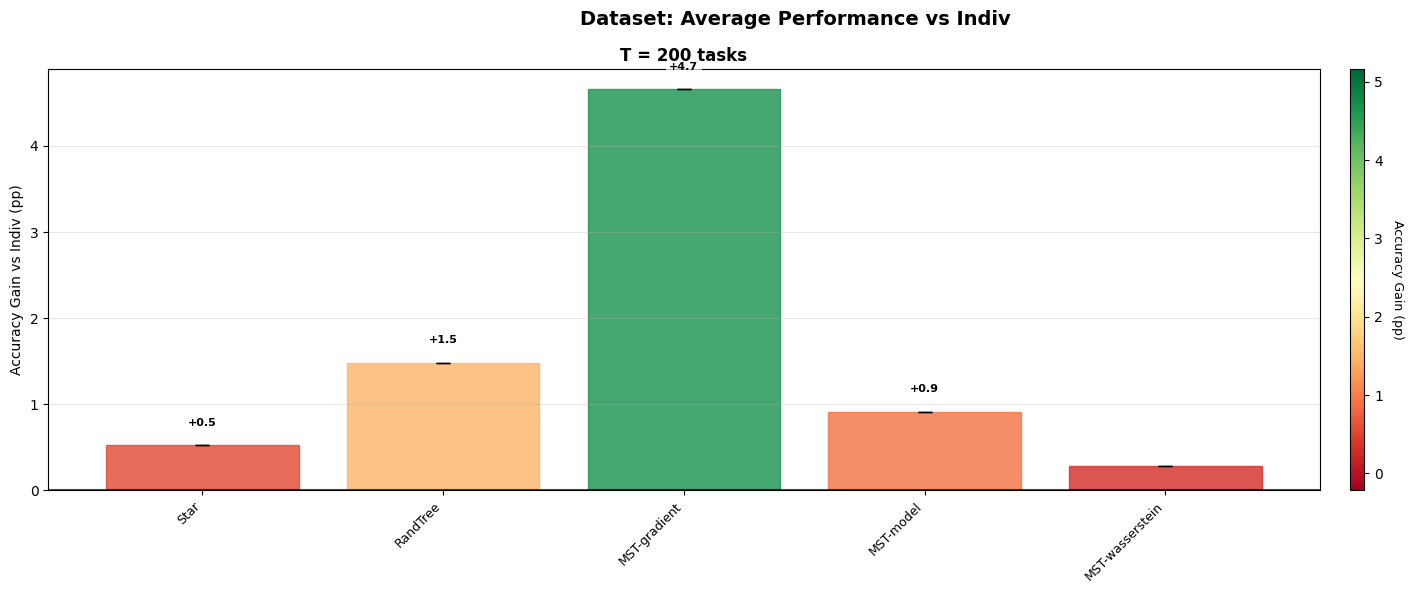

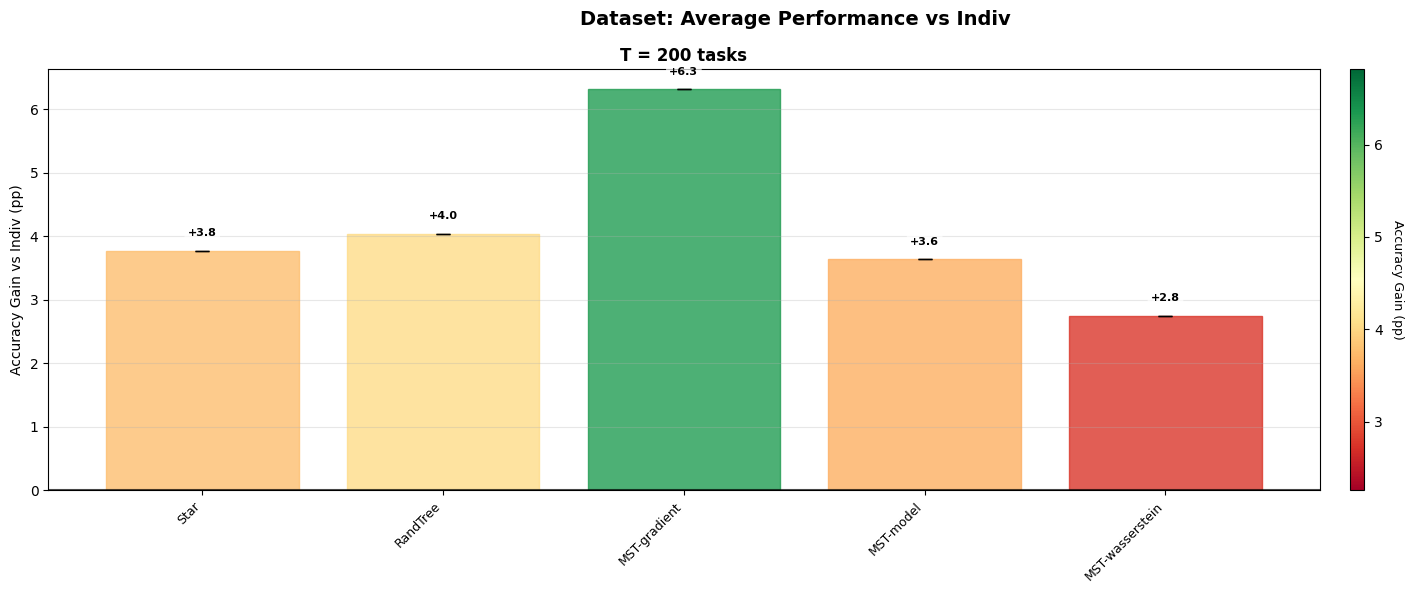

In [7]:
# clust-fmnist (K=5):  [Optuna] Best params: {'eta': 0.06952580822847765, 'reg': 0.0002809935574394071, 'b_proto_frac': 0.10056614814954187} (val loss=0.6109)
# clust-fmnist (K=20): [Optuna] Best params: {'eta': 0.2955513127628392, 'reg': 0.00790085761024867, 'b_proto_frac': 0.10070652999908704} (val loss=0.6531)
# homog-fmnist: [Optuna] Best params: {'eta': 0.1718769804412311, 'reg': 6.220746197213205e-06, 'b_proto_frac': 0.10145955166506501} (val loss=0.6416)

# clust-cifar (K=5): [Optuna] Best params: {'eta': 0.09364034189982912, 'reg': 0.00044369124423313027, 'b_proto_frac': 0.10113798086175203} (val loss=0.7131)
# clust-cifar (K=20): [Optuna] Best params: {'eta': 0.004094776572228638, 'reg': 0.0007332204837818093, 'b_proto_frac': 0.2076464040257699} (val loss=0.7300)
# homog-cifar: [Optuna] Best params: {'eta': 0.0670885289345722, 'reg': 0.00044369124423313027, 'b_proto_frac': 0.10113798086175203} (val loss=0.7300)

from collections import defaultdict

Ts = (200,)
Bs = (500,)
reps = 3
n_clusters = 5
n_train_per_task = 64
n_test_per_task = 128

mst_distance_types = (
    "gradient", 
    "model", 
    "wasserstein", 
)

dataset_to_run = ('fmnist', 'cifar')

# %%
if 'fmnist' in dataset_to_run:
    lr = 0.2955513127628392
    b_proto_frac = 0.1
    reg = 0.00790085761024867

    print("=" * 60)
    print("Fashion-MNIST Experiments")
    print("=" * 60)
    
    methods, results_fmnist, results_per_task_fmnist = run_image_classification_experiment(
        X_train_fmnist_pca, y_train_fmnist,
        X_test_fmnist_pca, y_test_fmnist,
        Ts=Ts,
        Bs=Bs,
        reps=reps,
        clustered=True,
        n_clusters=n_clusters,
        lr=lr,
        reg=reg,
        n_train_per_task=n_train_per_task, n_test_per_task=n_test_per_task,
        seed_fraction=b_proto_frac,
        mst_distance_types=mst_distance_types,
    )
    visualize_image_results_table(results_fmnist, methods, Ts, Bs)
    visualize_image_results_bars(results_fmnist, methods, Ts, Bs)


if 'cifar' in dataset_to_run:
    lr = 0.0670885289345722
    b_proto_frac = 0.1
    reg = 0.00044369124423313027

    print("\n" + "=" * 60)
    print("CIFAR-10 Experiments")
    print("=" * 60)

    methods, results_cifar, results_per_task_cifar = run_image_classification_experiment(
        X_train_cifar_pca, y_train_cifar,
        X_test_cifar_pca, y_test_cifar,
        Ts=Ts,
        Bs=Bs,
        reps=reps,
        clustered=True,
        n_clusters=n_clusters,
        lr=lr,
        reg=reg,
        n_train_per_task=n_train_per_task, n_test_per_task=n_test_per_task,
        seed_fraction=b_proto_frac,
        mst_distance_types=mst_distance_types,
    )
    visualize_image_results_table(results_cifar, methods, Ts, Bs)
    visualize_image_results_bars(results_cifar, methods, Ts, Bs)


In [8]:
print_statistical_summary(results_fmnist, methods, Ts, Bs)

latex_fmnist, df = image_results_to_latex_unified(
    results_fmnist, 
    methods, Ts, Bs,
    dataset_name="Fashion-MNIST",
    caption="Classification Accuracy (\\%)",
    label="tab:fmnist_results"
)
# with open("results_fminist2.tex", "w") as f:
#     f.write(latex_fmnist)
print(latex_fmnist)
print_statistical_summary(results_cifar, methods, Ts, Bs)

latex_cifar, df = image_results_to_latex_unified(
    results_cifar, 
    methods, Ts, Bs,
    dataset_name="CIFAR-10",
    caption="Classification Accuracy (\\%)",
    label="tab:cifar_results"
)
# with open("results_cifar2.tex", "w") as f:
#     f.write(latex_cifar)
print(latex_cifar)


STATISTICAL SUMMARY (Mean ± Std across repetitions)

T=200, B=500:
--------------------------------------------------
  Indiv               : 88.01 ± 6.12%
  Star                : 88.54 ± 5.67%
  CTL-RandTree        : 89.50 ± 4.13%
  CTL-MST-gradient    : 92.67 ± 3.41%
  CTL-MST-model       : 88.93 ± 5.48%
  CTL-MST-wasserstein : 88.30 ± 5.76%

STATISTICAL TESTS (vs Indiv)
T=200, B=500, Star           : Δ=+0.52% ± 0.75%, p=0.4297, d=0.567
T=200, B=500, CTL-RandTree   : Δ=+1.48% ± 2.61%, p=0.5059, d=0.464
T=200, B=500, CTL-MST-gradient: Δ=+4.66% ± 2.96%, p=0.1560, d=1.285
T=200, B=500, CTL-MST-model  : Δ=+0.91% ± 1.37%, p=0.4451, d=0.545
T=200, B=500, CTL-MST-wasserstein: Δ=+0.28% ± 2.00%, p=0.8595, d=0.116
\begin{table}[h]
\centering
\caption{Classification Accuracy (\%) (Fashion-MNIST)}
\label{tab:fmnist_results}
\resizebox{\textwidth}{!}{%
\begin{tabular}{cc|cccccc}
\toprule
\multicolumn{2}{c|}{Params} & \multicolumn{6}{c}{Methods} \\
$T$ & $B$ & Indiv & Star & CTL-RandTree & CTL-MS


FASHION-MNIST VISUALIZATIONS

Summary Table:

SUMMARY TABLE: Accuracy (%)
  T   B        Indiv         Star CTL-RandTree CTL-MST-gradient CTL-MST-model CTL-MST-wasserstein
200 500 88.01 ± 6.12 88.54 ± 5.67 89.50 ± 4.13     92.67 ± 3.41  88.93 ± 5.48        88.30 ± 5.76


Bar Chart (Improvement vs Indiv):


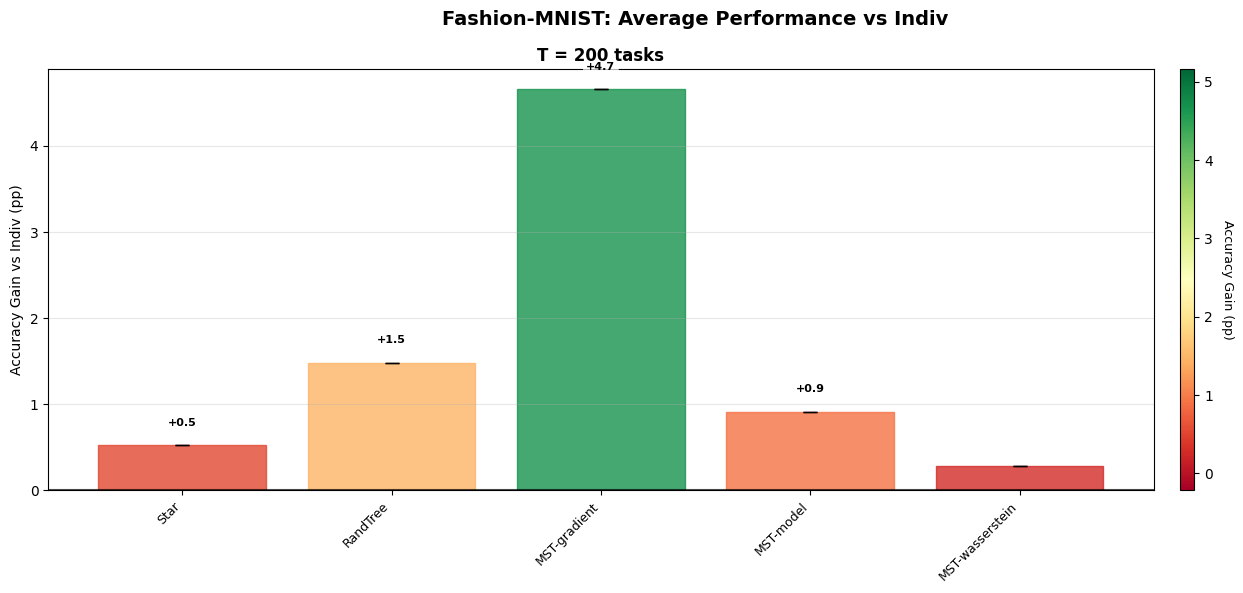


Heatmap (Improvement vs Indiv):


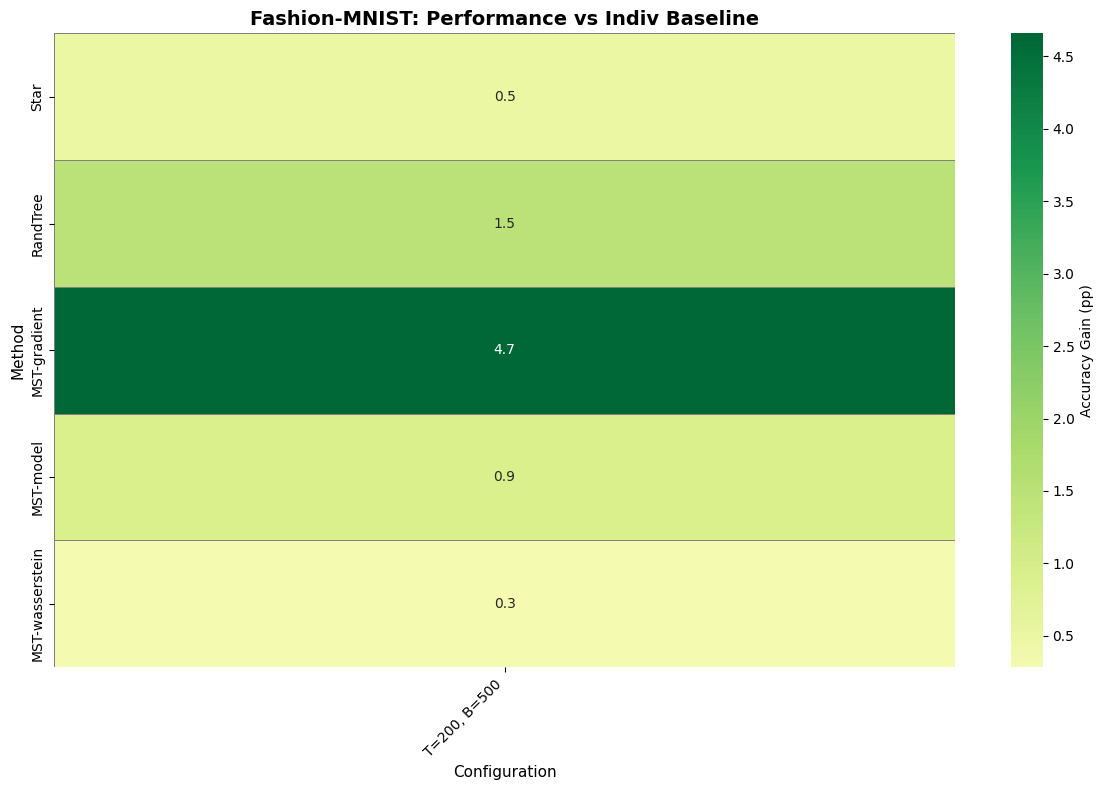


LaTeX Table:
\begin{table}[h]
\centering
\caption{Classification Accuracy on Fashion-MNIST (Fashion-MNIST)}
\label{tab:fmnist_results}
\resizebox{\textwidth}{!}{%
\begin{tabular}{cc|cccccc}
\toprule
\multicolumn{2}{c|}{Params} & \multicolumn{6}{c}{Methods} \\
$T$ & $B$ & Indiv & Star & CTL-RandTree & CTL-MST-gradient & CTL-MST-model & CTL-MST-wasserstein \\
\midrule
200 & 500 & $88.0 \pm 6.1$ & $88.5 \pm 5.7$ & $\underline{89.5 \pm 4.1}$ & $\mathbf{92.7 \pm 3.4}$ & $88.9 \pm 5.5$ & $88.3 \pm 5.8$ \\
\bottomrule
\end{tabular}
}
\end{table}

CIFAR-10 VISUALIZATIONS

Summary Table:

SUMMARY TABLE: Accuracy (%)
  T   B        Indiv         Star CTL-RandTree CTL-MST-gradient CTL-MST-model CTL-MST-wasserstein
200 500 63.04 ± 0.49 66.81 ± 1.07 67.08 ± 1.29     69.35 ± 0.91  66.67 ± 1.68        65.79 ± 1.50


Bar Chart (Improvement vs Indiv):


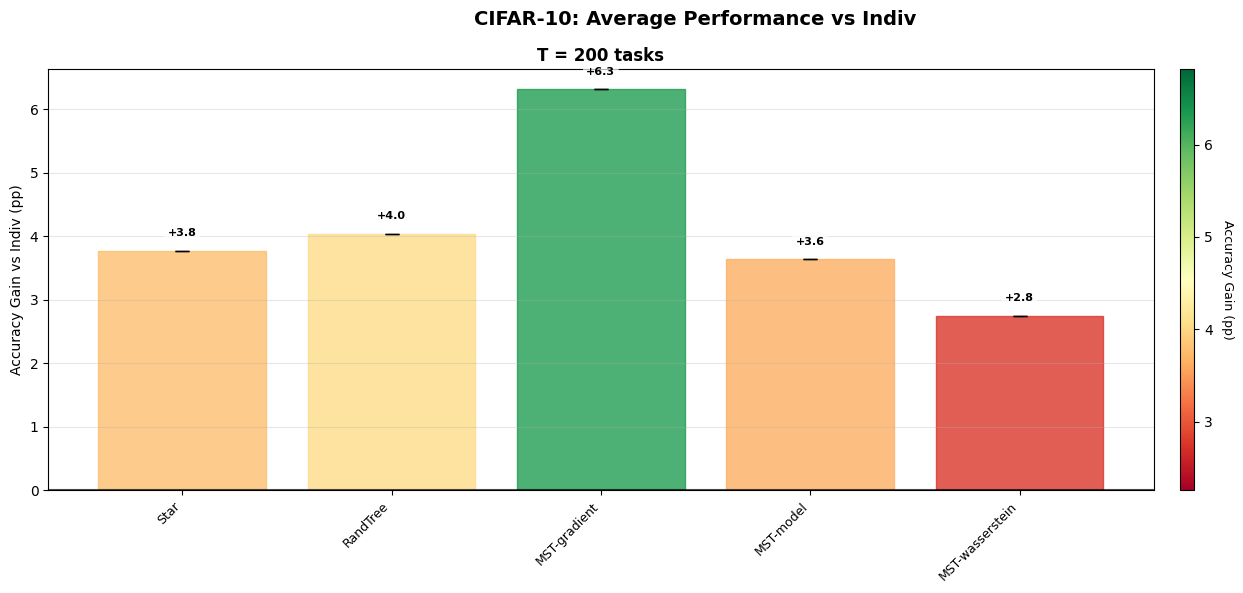


Heatmap (Improvement vs Indiv):


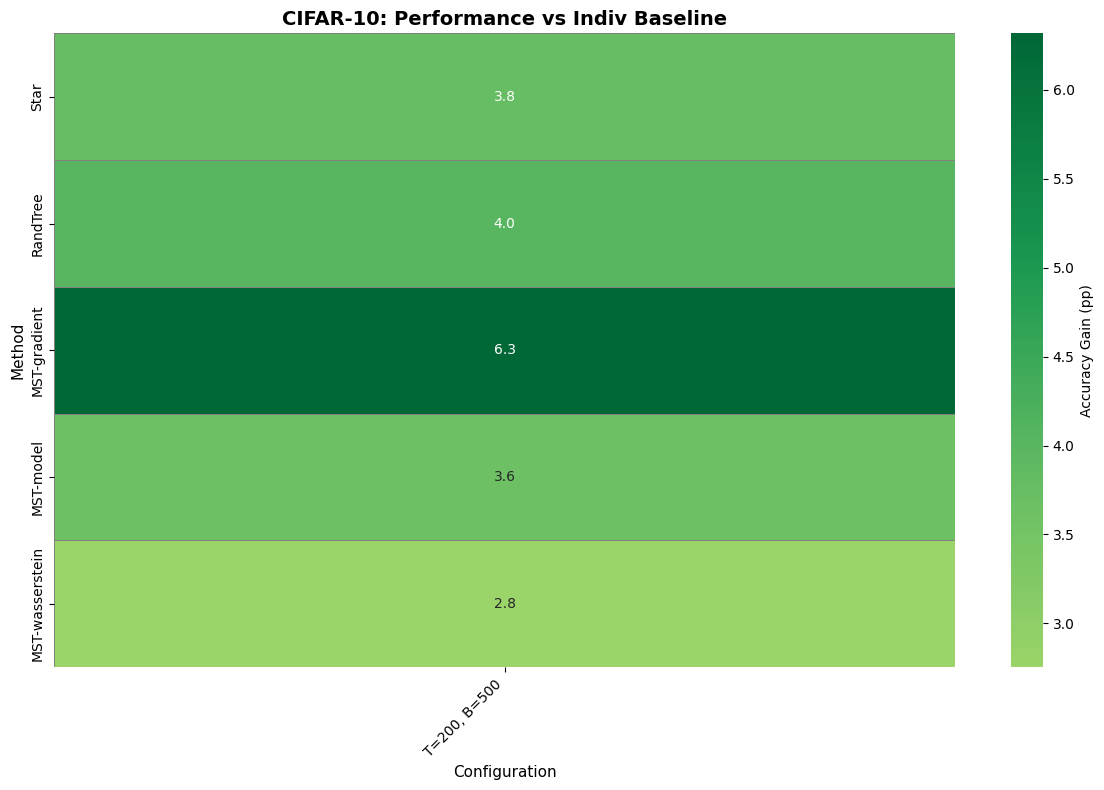


LaTeX Table:
\begin{table}[h]
\centering
\caption{Classification Accuracy on CIFAR-10 (CIFAR-10)}
\label{tab:cifar_results}
\resizebox{\textwidth}{!}{%
\begin{tabular}{cc|cccccc}
\toprule
\multicolumn{2}{c|}{Params} & \multicolumn{6}{c}{Methods} \\
$T$ & $B$ & Indiv & Star & CTL-RandTree & CTL-MST-gradient & CTL-MST-model & CTL-MST-wasserstein \\
\midrule
200 & 500 & $63.0 \pm 0.5$ & $66.8 \pm 1.1$ & $\underline{67.1 \pm 1.3}$ & $\mathbf{69.4 \pm 0.9}$ & $66.7 \pm 1.7$ & $65.8 \pm 1.5$ \\
\bottomrule
\end{tabular}
}
\end{table}

COMBINED COMPARISON


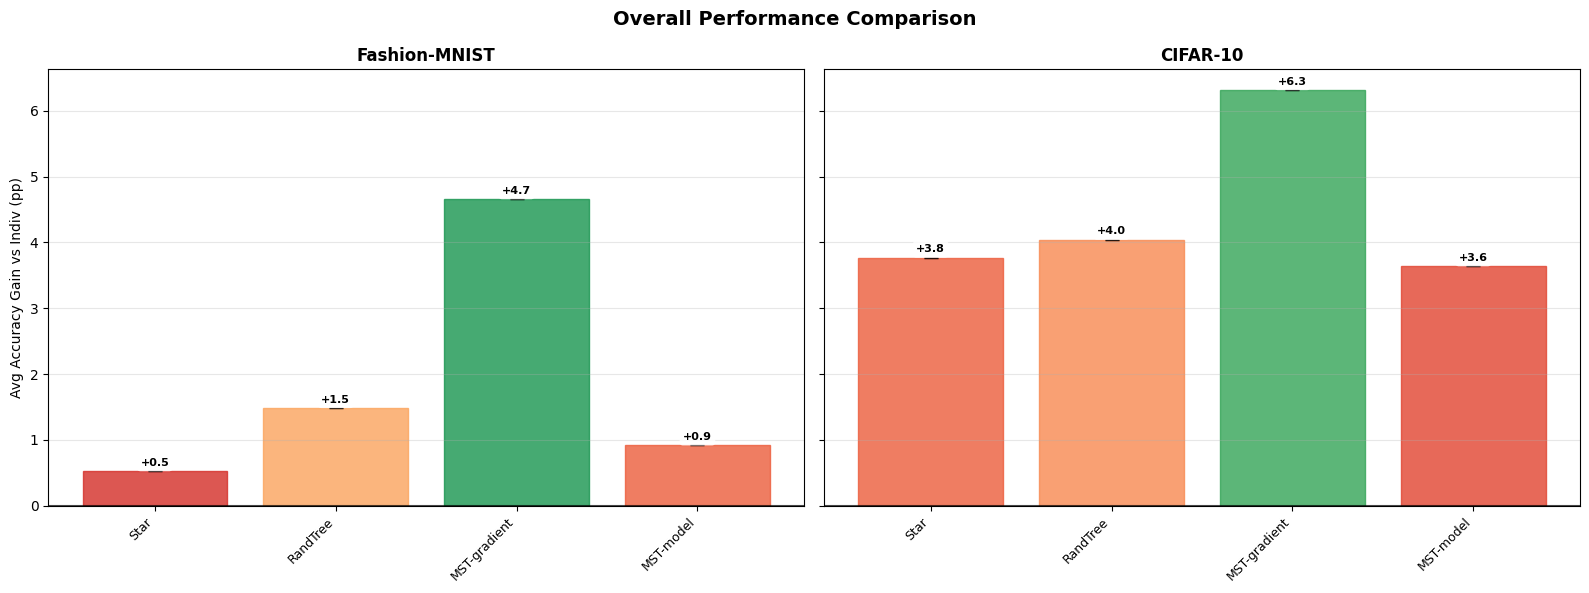


Summary Statistics:
--------------------------------------------------------------------------------

Fashion-MNIST:
  Method                    Mean Gain (pp)  Std (pp)   Best Config
  ----------------------------------------------------------------------
  Star                        +0.52             0.00    T=200, B=500
  RandTree                    +1.48             0.00    T=200, B=500
  MST-gradient                +4.66             0.00    T=200, B=500
  MST-model                   +0.91             0.00    T=200, B=500
  MST-wasserstein             +0.28             0.00    T=200, B=500

CIFAR-10:
  Method                    Mean Gain (pp)  Std (pp)   Best Config
  ----------------------------------------------------------------------
  Star                        +3.77             0.00    T=200, B=500
  RandTree                    +4.04             0.00    T=200, B=500
  MST-gradient                +6.32             0.00    T=200, B=500
  MST-model                   +3.64    

In [11]:
method_colors = {
    "Star": "#3498db",
    "CTL-RandTree": "#9b59b6",
    "CTL-MST-feature": "#e74c3c",
    "CTL-MST-target": "#e67e22",
    "CTL-MST-gradient": "#f39c12",
    "CTL-MST-model": "#16a085",
    "CTL-MST-kl": "#27ae60",
    "CTL-MST-wasserstein": "#2980b9",
    "CTL-MST-mmd_feature": "#8e44ad",
    "CTL-MST-mean_cov_feature": "#c0392b",
    "CTL-MST-js_target": "#d35400",
    "CTL-MST-cka": "#2c3e50",
}

if 'fmnist' in dataset_to_run and 'results_fmnist' in locals():
    print("\n" + "="*60)
    print("FASHION-MNIST VISUALIZATIONS")
    print("="*60)
    
    # Summary table
    print("\nSummary Table:")
    df_fmnist = visualize_image_results_table(
        results_fmnist, methods, Ts, Bs, metric_name="Accuracy"
    )
    
    # Bar chart
    print("\nBar Chart (Improvement vs Indiv):")
    fig_bar_fmnist, axes_bar_fmnist = visualize_image_results_bars(
        results_fmnist, methods, Ts, Bs,
        colors=method_colors,
        baseline="Indiv",
        dataset_name="Fashion-MNIST",
        figsize=(max(14, len(Ts) * 5), 6)
    )
    plt.show()
    
    # Heatmap
    print("\nHeatmap (Improvement vs Indiv):")
    fig_heat_fmnist, ax_heat_fmnist = visualize_image_results_heatmap(
        results_fmnist, methods, Ts, Bs,
        baseline="Indiv",
        dataset_name="Fashion-MNIST",
        figsize=(max(12, len(Ts) * len(Bs) * 0.8), max(8, len(methods) * 0.5))
    )
    plt.show()
    
    # LaTeX table
    print("\nLaTeX Table:")
    latex_fmnist, df_latex_fmnist = image_results_to_latex_unified(
        results_fmnist, methods, Ts, Bs,
        dataset_name="Fashion-MNIST",
        caption="Classification Accuracy on Fashion-MNIST",
        label="tab:fmnist_results",
        show_std=True
    )
    print(latex_fmnist)
    with open("results_fmnist.tex", "w") as f:
        f.write(latex_fmnist)

if 'cifar' in dataset_to_run and 'results_cifar' in locals():
    print("\n" + "="*60)
    print("CIFAR-10 VISUALIZATIONS")
    print("="*60)
    
    # Summary table
    print("\nSummary Table:")
    df_cifar = visualize_image_results_table(
        results_cifar, methods, Ts, Bs, metric_name="Accuracy"
    )
    
    # Bar chart
    print("\nBar Chart (Improvement vs Indiv):")
    fig_bar_cifar, axes_bar_cifar = visualize_image_results_bars(
        results_cifar, methods, Ts, Bs,
        colors=method_colors,
        baseline="Indiv",
        dataset_name="CIFAR-10",
        figsize=(max(14, len(Ts) * 5), 6)
    )
    plt.show()
    
    # Heatmap
    print("\nHeatmap (Improvement vs Indiv):")
    fig_heat_cifar, ax_heat_cifar = visualize_image_results_heatmap(
        results_cifar, methods, Ts, Bs,
        baseline="Indiv",
        dataset_name="CIFAR-10",
        figsize=(max(12, len(Ts) * len(Bs) * 0.8), max(8, len(methods) * 0.5))
    )
    plt.show()
    
    # LaTeX table
    print("\nLaTeX Table:")
    latex_cifar, df_latex_cifar = image_results_to_latex_unified(
        results_cifar, methods, Ts, Bs,
        dataset_name="CIFAR-10",
        caption="Classification Accuracy on CIFAR-10",
        label="tab:cifar_results",
        show_std=True
    )
    print(latex_cifar)
    with open("results_cifar.tex", "w") as f:
        f.write(latex_cifar)

if 'results_fmnist' in locals() and 'results_cifar' in locals():
    print("\n" + "="*60)
    print("COMBINED COMPARISON")
    print("="*60)
    
    # Side-by-side bar charts
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    
    for dataset_idx, (dataset_name, dataset_results) in enumerate([
        ("Fashion-MNIST", results_fmnist),
        ("CIFAR-10", results_cifar)
    ]):
        ax = axes[dataset_idx]
        
        # Compute average improvement across all configs
        method_improvements = []
        method_stds = []
        method_labels = []
        
        for method in methods:
            if method in ["Indiv", "CTL-MST-wasserstein"]:
                continue
            
            improvements = []
            for T in Ts:
                for B in Bs:
                    key = (T, B)
                    baseline_vals = np.array(dataset_results["Indiv"].get(key, []))
                    method_vals = np.array(dataset_results[method].get(key, []))
                    
                    baseline_vals = baseline_vals[~np.isnan(baseline_vals)]
                    method_vals = method_vals[~np.isnan(method_vals)]
                    
                    if len(baseline_vals) > 0 and len(method_vals) > 0:
                        improvement = (method_vals.mean() - baseline_vals.mean()) * 100
                        improvements.append(improvement)
            
            if len(improvements) > 0:
                method_improvements.append(np.mean(improvements))
                method_stds.append(np.std(improvements))
                label = method.replace('CTL-MST-', 'MST-').replace('CTL-', '')
                method_labels.append(label)
            else:
                method_improvements.append(0)
                method_stds.append(0)
                label = method.replace('CTL-MST-', 'MST-').replace('CTL-', '')
                method_labels.append(label)
        
        x = np.arange(len(method_labels))
        bars = ax.bar(
            x, method_improvements, 
            yerr=method_stds,
            capsize=5,
            alpha=0.8,
            error_kw={'linewidth': 1.5, 'ecolor': 'black', 'alpha': 0.6}
        )
        
        # Color by performance
        if len(method_improvements) > 0 and max(method_improvements) > min(method_improvements):
            norm = plt.Normalize(
                vmin=min(method_improvements) - 0.5, 
                vmax=max(method_improvements) + 0.5
            )
            cmap = plt.cm.RdYlGn
            for bar, mean in zip(bars, method_improvements):
                bar.set_color(cmap(norm(mean)))
        
        ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.7)
        ax.set_xticks(x)
        ax.set_xticklabels(method_labels, rotation=45, ha='right', fontsize=9)
        ax.set_title(dataset_name, fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add value labels on bars
        for i, (mean, std) in enumerate(zip(method_improvements, method_stds)):
            if abs(mean) > 0.3:  # Only label if improvement > 0.3pp
                y_offset = std + 0.05 if mean > 0 else -std - 0.05
                ax.text(
                    i, mean + y_offset,
                    f"{mean:+.1f}",
                    ha='center', 
                    va='bottom' if mean > 0 else 'top',
                    fontsize=8, 
                    fontweight='bold',
                    bbox=dict(
                        boxstyle='round,pad=0.3', 
                        facecolor='white', 
                        alpha=0.8, 
                        edgecolor='none'
                    )
                )
        
        if dataset_idx == 0:
            ax.set_ylabel("Avg Accuracy Gain vs Indiv (pp)", fontsize=10)
    
    fig.suptitle("Overall Performance Comparison", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig("combined_comparison_bar_chart.pdf", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print summary statistics
    print("\nSummary Statistics:")
    print("-" * 80)
    
    for dataset_name, dataset_results in [
        ("Fashion-MNIST", results_fmnist),
        ("CIFAR-10", results_cifar)
    ]:
        print(f"\n{dataset_name}:")
        print(f"  {'Method':<25} {'Mean Gain (pp)':<15} {'Std (pp)':<10} {'Best Config'}")
        print("  " + "-" * 70)
        
        for method in methods:
            if method == "Indiv":
                continue
            
            improvements = []
            best_improvement = -np.inf
            best_config = None
            
            for T in Ts:
                for B in Bs:
                    key = (T, B)
                    baseline_vals = np.array(dataset_results["Indiv"].get(key, []))
                    method_vals = np.array(dataset_results[method].get(key, []))
                    
                    baseline_vals = baseline_vals[~np.isnan(baseline_vals)]
                    method_vals = method_vals[~np.isnan(method_vals)]
                    
                    if len(baseline_vals) > 0 and len(method_vals) > 0:
                        improvement = (method_vals.mean() - baseline_vals.mean()) * 100
                        improvements.append(improvement)
                        
                        if improvement > best_improvement:
                            best_improvement = improvement
                            best_config = f"T={T}, B={B}"
            
            if len(improvements) > 0:
                mean_gain = np.mean(improvements)
                std_gain = np.std(improvements)
                label = method.replace('CTL-MST-', 'MST-').replace('CTL-', '')
                print(f"  {label:<25} {mean_gain:>+7.2f}          {std_gain:>7.2f}    {best_config}")

print("\n" + "="*60)
print("ALL VISUALIZATIONS COMPLETE")
print("="*60)